Please upload your Image:


Saving ArticlePic-Test.png to ArticlePic-Test.png


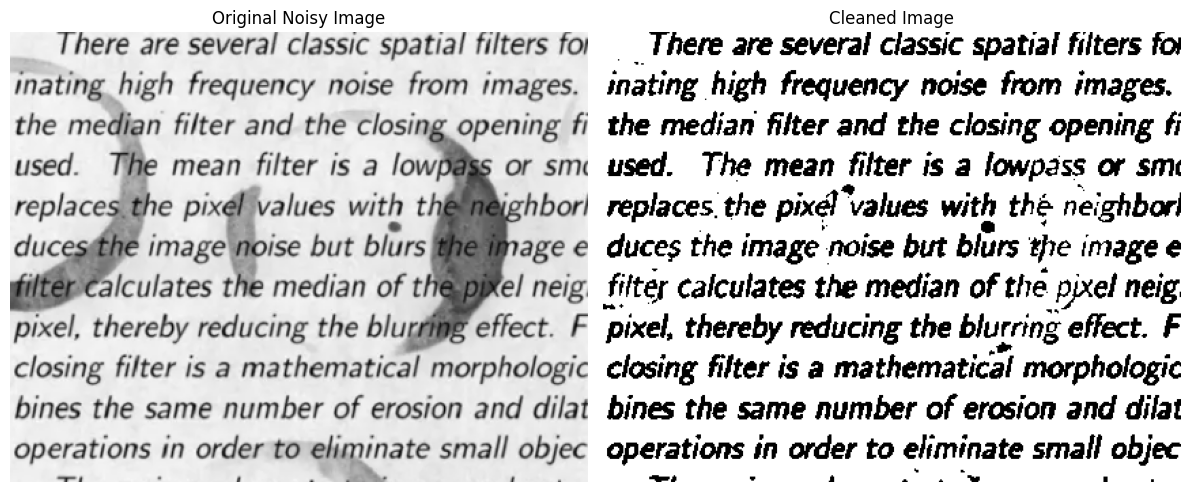


Result saved as: cleaned_ArticlePic-Test.png


In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image

def process_document(image_path_or_array):
    # Load and prepare image
    if isinstance(image_path_or_array, str):
        img = cv2.imread(image_path_or_array)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = image_path_or_array

    # Convert to grayscale using luminance formula
    if len(img.shape) == 3:
        gray = np.dot(img[...,:3], [0.299, 0.587, 0.114]).astype(np.uint8)
    else:
        gray = img

    # Estimate background using median filter
    kernel_size = 21
    pad = kernel_size // 2
    h, w = gray.shape

    # Pad the image with reflection to handle borders
    padded = np.pad(gray, pad, mode='reflect')

    # Apply median filter to get background estimate
    background = np.zeros_like(gray)
    for i in range(h):
        for j in range(w):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            background[i, j] = np.median(window)

    # Remove background
    cleaned = np.clip(background.astype(np.int16) - gray.astype(np.int16), 0, 255).astype(np.uint8)

    # Normalize to full range
    min_val, max_val = cleaned.min(), cleaned.max()
    if max_val > min_val:
        normalized = ((cleaned - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    else:
        normalized = cleaned

    # Invertion
    inverted = 255 - normalized

    # Adaptive threshold using mean value
    threshold_value = np.mean(inverted)
    binary = (inverted > threshold_value).astype(np.uint8) * 255

    return binary

# Upload and process
print("Please upload your Image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read the uploaded image
image = Image.open(io.BytesIO(uploaded[filename]))
image_array = np.array(image)

# Process through pipeline
result = process_document(image_array)

# Display results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title('Original Noisy Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result, cmap='gray')
plt.title('Cleaned Image')
plt.axis('off')

plt.tight_layout()
plt.show()

# Optional: Save the result
output_filename = 'cleaned_' + filename
Image.fromarray(result).save(output_filename)
print(f"\nResult saved as: {output_filename}")